# Evaluación y comparativa final de los modelos

En este notebook se realiza la evaluación y comparación final de los distintos sistemas de recomendación desarrollados.

Los modelos analizados son:

- Filtrado colaborativo basado en usuarios.
- Factores latentes.
- Factores latentes híbrido con popularidad.
- Deep Learning para predicción de valoraciones.
- Deep Learning orientado a ranking.

La comparación se realizará teniendo en cuenta que no todos los modelos han sido diseñados con el mismo objetivo. Por un lado, se analizará la capacidad de predicción de valoraciones mediante métricas como RMSE y MAE. Por otro, se estudiará la capacidad de generar rankings de recomendación mediante métricas específicas como Hit Rate y NDCG.

Finalmente, se realizará una comparación global del comportamiento de los modelos y de las recomendaciones generadas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
BASE_DIR = Path("..")

DATA_DIR = (
    BASE_DIR
    / "data"
    / "raw"
    / "ml-latest-small"
)

MODELS_DIR = (
    BASE_DIR
    / "models"
)

In [4]:
ratings = pd.read_csv(
    DATA_DIR / "ratings.csv"
)

movies = pd.read_csv(
    DATA_DIR / "movies.csv"
)

print("Valoraciones:", ratings.shape)
print("Películas:", movies.shape)
print("Usuarios:", ratings["userId"].nunique())

Valoraciones: (100836, 4)
Películas: (9742, 3)
Usuarios: 610


## 1. Estrategia de evaluación

Los modelos desarrollados no persiguen exactamente el mismo objetivo, por lo que la evaluación se divide en dos bloques principales.

### Predicción de valoraciones

Los modelos capaces de estimar directamente la valoración que un usuario asignaría a una película se comparan mediante:

- RMSE (Root Mean Squared Error).
- MAE (Mean Absolute Error).

Estas métricas permiten medir la diferencia entre las valoraciones reales y las predichas.

### Calidad del ranking

Para los modelos orientados a generar listas ordenadas de recomendaciones se utilizan métricas como:

- Hit Rate @ 10.
- NDCG @ 10.

Estas métricas permiten evaluar si las películas relevantes aparecen dentro de las primeras posiciones del ranking y la calidad de su ordenación.

Las métricas de ambos grupos se analizarán por separado, ya que miden objetivos diferentes.

## 2. Resultados de los modelos desarrollados

En primer lugar, se recopilan los resultados obtenidos durante la evaluación individual de cada uno de los modelos desarrollados. Esto permite realizar posteriormente una comparación conjunta manteniendo las métricas y condiciones utilizadas durante su evaluación.

In [5]:
resultados_prediccion = pd.DataFrame({
    "Modelo": [
        "Filtrado colaborativo",
        "Factores latentes",
        "Deep Learning híbrido"
    ],
    "MAE": [
        0.6325,
        0.6003,
        0.5874
    ],
    "RMSE": [
        0.8257,
        0.7791,
        0.7681
    ]
})

resultados_prediccion

,Modelo,MAE,RMSE
0,Filtrado colaborativo,0.6325,0.8257
1,Factores latentes,0.6003,0.7791
2,Deep Learning híbrido,0.5874,0.7681


### 2.1 Comparación de la predicción de valoraciones

Para realizar una comparación directa entre los modelos de filtrado colaborativo, factores latentes y Deep Learning se consideran las 3.076 interacciones comunes para las que los tres modelos pueden generar una predicción.

De esta forma, los valores de MAE y RMSE se calculan sobre el mismo conjunto de datos, evitando comparar resultados obtenidos bajo condiciones diferentes.

Los resultados muestran una reducción progresiva del error. El filtrado colaborativo obtiene los valores más elevados, mientras que el modelo de factores latentes consigue mejorar ambas métricas. Finalmente, el modelo Deep Learning obtiene el menor MAE y RMSE de los tres modelos evaluados.

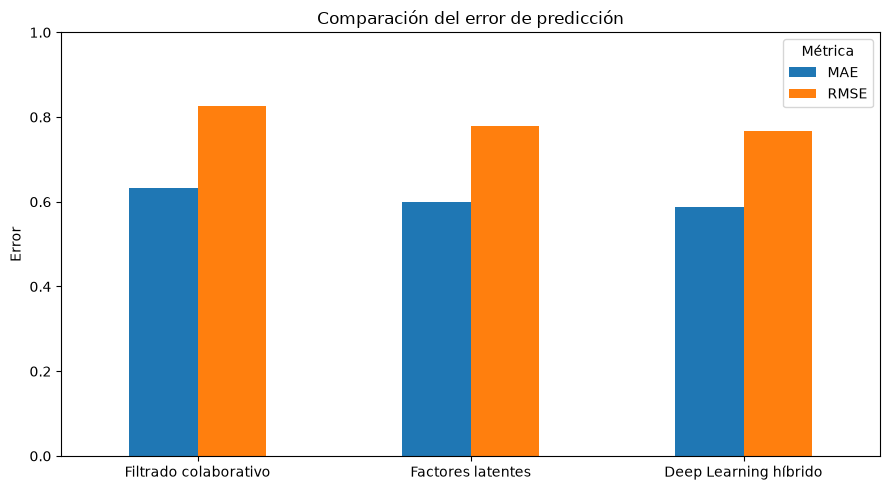

In [6]:
# Comparación gráfica de MAE y RMSE

resultados_grafica = resultados_prediccion.set_index("Modelo")

ax = resultados_grafica[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Comparación del error de predicción")
plt.ylabel("Error")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

### 2.2 Evaluación de la recomendación Top-N

La capacidad de predecir correctamente una valoración no implica necesariamente que un modelo genere el mejor ranking de recomendaciones. Por este motivo, además de las métricas MAE y RMSE, se analizan los modelos diseñados específicamente para mejorar la calidad de las recomendaciones Top-N.

Estos modelos se evalúan mediante métricas orientadas al ranking y a la recuperación de elementos relevantes. Debido a que los protocolos y métricas utilizados no son idénticos, sus resultados se presentan de forma separada y no se comparan directamente entre sí.

In [7]:
resultados_hibrido = pd.DataFrame({
    "Modelo": [
        "Factores latentes",
        "Popularidad",
        "Híbrido MF + popularidad"
    ],
    "Precision@10": [
        0.3805,
        0.5498,
        0.5543
    ],
    "Recall@10": [
        0.3454,
        0.5664,
        0.5730
    ]
})

resultados_hibrido

,Modelo,Precision@10,Recall@10
0,Factores latentes,0.3805,0.3454
1,Popularidad,0.5498,0.5664
2,Híbrido MF + popularidad,0.5543,0.5730


#### Resultados del modelo híbrido

El modelo basado únicamente en factores latentes obtiene una Precision@10 de 0.3805 y un Recall@10 de 0.3454. Estos resultados mejoran considerablemente al introducir la popularidad de las películas como información adicional.

El baseline basado únicamente en popularidad alcanza una Precision@10 de 0.5498 y un Recall@10 de 0.5664. Finalmente, el modelo híbrido, utilizando un peso del 20 % para los factores latentes y del 80 % para la popularidad, obtiene los mejores resultados, con una Precision@10 de 0.5543 y un Recall@10 de 0.5730.

Aunque la mejora respecto al modelo de popularidad es reducida, el resultado muestra que la combinación de ambas fuentes de información permite mantener el buen rendimiento proporcionado por la popularidad e incorporar al mismo tiempo información personalizada procedente de los factores latentes.

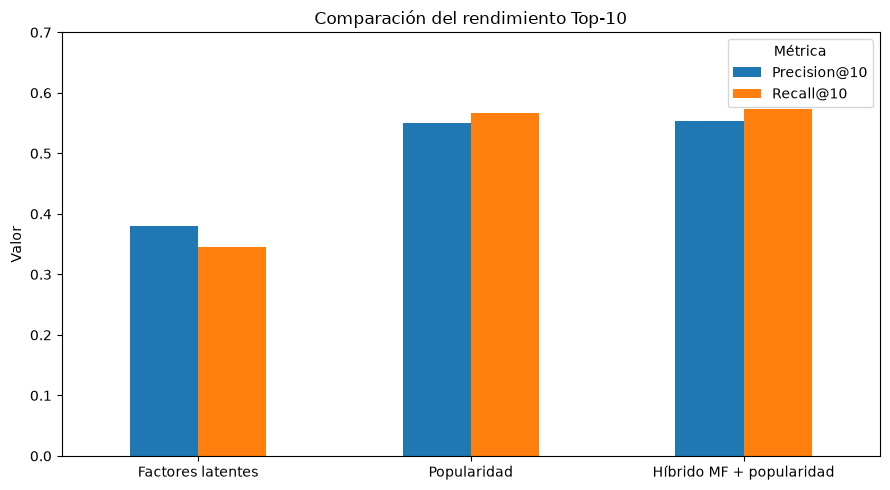

In [8]:
# Comparación de Precision@10 y Recall@10

resultados_hibrido_grafica = resultados_hibrido.set_index("Modelo")

ax = resultados_hibrido_grafica[["Precision@10", "Recall@10"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Comparación del rendimiento Top-10")
plt.ylabel("Valor")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)

plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

### 2.3 Evaluación del modelo Deep Learning orientado a ranking

El último modelo desarrollado modifica el objetivo del aprendizaje. En lugar de tratar de predecir directamente la valoración que un usuario asignaría a una película, el modelo aprende a estimar la relevancia de los elementos con el objetivo de ordenarlos correctamente dentro de una lista de recomendaciones.

Por este motivo, su evaluación se realiza mediante métricas específicas de ranking, principalmente Hit Rate@10 (HR@10) y NDCG@10. Como referencia se utiliza un modelo baseline basado en popularidad.

In [9]:
resultados_ranking = pd.DataFrame({
    "Modelo": [
        "Baseline popularidad",
        "Deep Learning Ranking"
    ],
    "HR@10": [
        0.2712,
        0.5612
    ],
    "NDCG@10": [
        0.1551,
        0.4388
    ],
    "Posición media": [
        48.68,
        19.24
    ],
    "Posición mediana": [
        38,
        7
    ]
})

resultados_ranking

,Modelo,HR@10,NDCG@10,Posición media,Posición mediana
0,Baseline popularidad,0.2712,0.1551,48.68,38
1,Deep Learning Ranking,0.5612,0.4388,19.24,7


#### Resultados del Deep Learning Ranking

El modelo Deep Learning orientado a ranking mejora claramente al baseline de popularidad en todas las métricas consideradas.

El HR@10 aumenta de 0.2712 a 0.5612, lo que indica que el modelo consigue situar el elemento relevante dentro de las diez primeras posiciones en una proporción considerablemente mayor de casos.

El NDCG@10 también mejora de 0.1551 a 0.4388, mostrando que no solo recupera más elementos relevantes, sino que además tiende a colocarlos en posiciones más altas dentro del ranking.

Este comportamiento también se refleja en la posición media y mediana. La posición media del elemento relevante desciende de 48.68 a 19.24, mientras que la posición mediana pasa de 38 a 7.

Estos resultados justifican el desarrollo de un modelo específicamente orientado a ranking, ya que presenta un comportamiento mucho más adecuado para la generación de recomendaciones Top-N que un enfoque basado únicamente en popularidad.

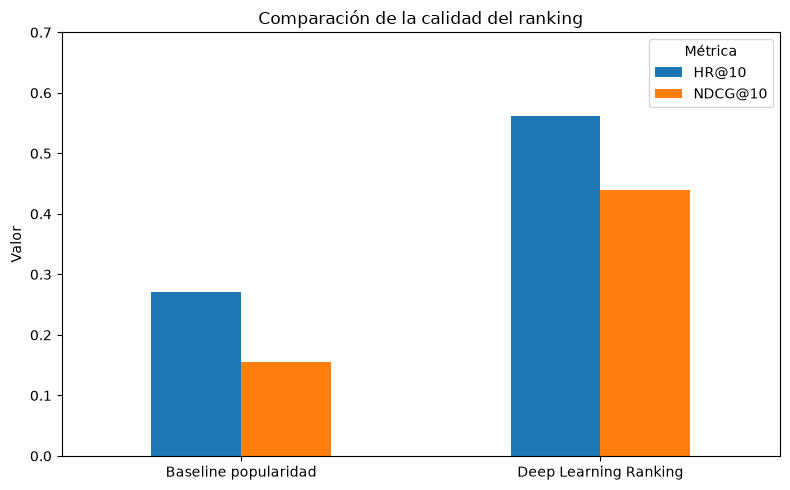

In [10]:
resultados_ranking_grafica = (
    resultados_ranking
    .set_index("Modelo")
)

ax = resultados_ranking_grafica[
    ["HR@10", "NDCG@10"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparación de la calidad del ranking")
plt.ylabel("Valor")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 0.7)

plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

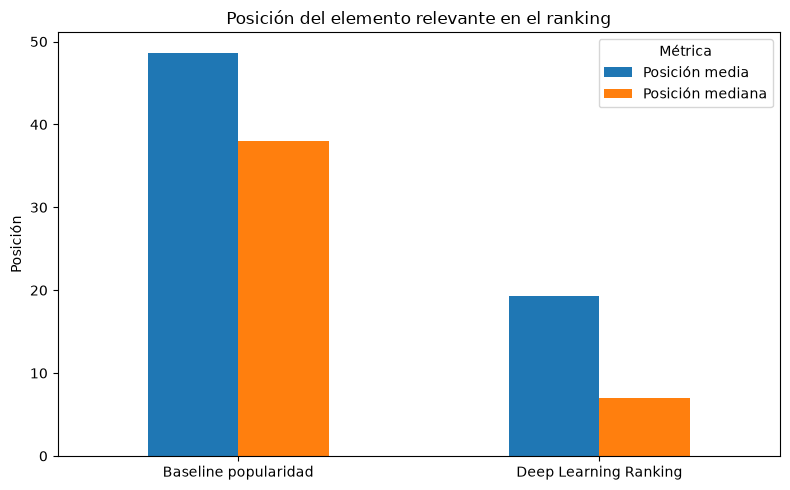

In [11]:
# Comparación de la posición del elemento relevante

ax = resultados_ranking_grafica[
    ["Posición media", "Posición mediana"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Posición del elemento relevante en el ranking")
plt.ylabel("Posición")
plt.xlabel("")
plt.xticks(rotation=0)

plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

## 3. Comparación global de los modelos

In [12]:
comparacion_global = pd.DataFrame({
    "Modelo": [
        "Filtrado colaborativo",
        "Factores latentes",
        "Híbrido MF + popularidad",
        "Deep Learning",
        "Deep Learning Ranking"
    ],
    "Objetivo principal": [
        "Predicción de ratings",
        "Predicción de ratings",
        "Recomendación Top-N",
        "Predicción de ratings",
        "Ranking Top-N"
    ],
    "Principal fortaleza": [
        "Simplicidad e interpretabilidad",
        "Representación latente usuario-película",
        "Equilibrio entre personalización y popularidad",
        "Menor error de predicción",
        "Mejor ordenación de elementos relevantes"
    ]
})

comparacion_global

,Modelo,Objetivo principal,Principal fortaleza
0,Filtrado colaborativo,Predicción de ratings,Simplicidad e interpretabilidad
1,Factores latentes,Predicción de ratings,Representación latente usuario-película
2,Híbrido MF + popularidad,Recomendación Top-N,Equilibrio entre personalización y popularidad
3,Deep Learning,Predicción de ratings,Menor error de predicción
4,Deep Learning Ranking,Ranking Top-N,Mejor ordenación de elementos relevantes


### 3.1 Interpretación global

Los resultados obtenidos muestran que no existe un único modelo que pueda considerarse superior en todos los aspectos, ya que los distintos enfoques responden a objetivos diferentes dentro de un sistema de recomendación.

El filtrado colaborativo constituye el modelo más sencillo e interpretable. Permite generar recomendaciones a partir de usuarios con comportamientos similares, aunque presenta una cobertura limitada y depende de que existan suficientes valoraciones compartidas entre los usuarios.

Los factores latentes permiten representar usuarios y películas mediante características aprendidas automáticamente a partir de las valoraciones. Este enfoque mejora la predicción de ratings respecto al filtrado colaborativo cuando ambos se evalúan sobre las mismas interacciones, aunque su rendimiento como generador de recomendaciones Top-N resultó limitado.

La incorporación de popularidad al modelo de factores latentes permitió mejorar considerablemente Precision@10 y Recall@10. El modelo híbrido consiguió superar ligeramente al baseline de popularidad, manteniendo además un componente de personalización procedente de los factores latentes.

El modelo Deep Learning orientado a la predicción de ratings obtuvo los menores valores de MAE y RMSE en la comparación realizada sobre las interacciones comunes, mostrando la mayor capacidad predictiva de los modelos desarrollados con este objetivo.

Finalmente, el modelo Deep Learning Ranking aborda directamente el problema de recomendación como una tarea de ordenación de elementos. Los resultados obtenidos frente al baseline de popularidad muestran una mejora considerable tanto en HR@10 como en NDCG@10 y en la posición ocupada por los elementos relevantes.

En conjunto, los experimentos muestran una evolución desde modelos centrados en predecir valoraciones hacia modelos específicamente diseñados para generar rankings de recomendación. Esta diferencia resulta especialmente relevante, ya que una menor desviación en la predicción de ratings no garantiza necesariamente una mejor lista de recomendaciones.

## 4. Selección de modelos para la aplicación

La aplicación desarrollada permite utilizar diferentes modelos de recomendación con el objetivo de mostrar de forma práctica el comportamiento de los distintos enfoques estudiados durante el proyecto.

La integración de varios modelos no implica que todos presenten el mismo rendimiento ni que persigan exactamente el mismo objetivo. El filtrado colaborativo, los factores latentes y el modelo Deep Learning de predicción permiten observar diferentes formas de estimar las preferencias de los usuarios, mientras que los modelos híbrido y Deep Learning Ranking están más orientados a la generación de listas de recomendaciones.

Los resultados obtenidos muestran además la importancia de distinguir entre la predicción de valoraciones y la generación de rankings. En la comparación realizada sobre las 3.076 interacciones comunes, el modelo Deep Learning obtuvo el menor error de predicción, con un MAE de 0.5874 y un RMSE de 0.7681.

Sin embargo, para un sistema de recomendación el objetivo final no consiste únicamente en estimar correctamente una valoración, sino en seleccionar y ordenar películas que puedan resultar relevantes para el usuario. En este sentido, el desarrollo del modelo Deep Learning Ranking supone una evolución del sistema hacia un enfoque específicamente diseñado para la recomendación Top-N.

Este modelo obtuvo un HR@10 de 0.5612 y un NDCG@10 de 0.4388, superando claramente al baseline de popularidad. Además, la posición mediana del elemento relevante se redujo de 38 a 7, mostrando una mejora importante en la capacidad de situar elementos relevantes en las primeras posiciones.

Por otra parte, el modelo híbrido de factores latentes y popularidad también mostró resultados positivos, alcanzando una Precision@10 de 0.5543 y un Recall@10 de 0.5730 para la configuración analizada con un 20 % de peso para los factores latentes y un 80 % para la popularidad.

Por tanto, la aplicación mantiene los distintos modelos como parte del carácter experimental y comparativo del proyecto, mientras que los modelos orientados específicamente a Top-N representan la evolución más directamente relacionada con el objetivo final de un sistema recomendador.

## 5. Comportamiento según el tipo de usuario

### 5.1 Usuarios con historial de valoraciones

Para los usuarios existentes en el conjunto de datos se dispone de un historial previo de valoraciones. Esta información permite aplicar directamente los modelos entrenados, ya que el usuario forma parte de las estructuras utilizadas durante el aprendizaje.

En este escenario, los distintos modelos pueden aprovechar la información histórica del usuario para estimar sus preferencias y generar recomendaciones sobre películas que todavía no ha valorado.

Este caso representa el escenario más favorable para los modelos colaborativos, puesto que existe suficiente información previa sobre el comportamiento del usuario.

### 5.2 Usuarios nuevos y problema de cold-start

Un usuario nuevo no dispone inicialmente de un historial de valoraciones dentro del conjunto de datos. Esta situación constituye el denominado problema de cold-start, ya que los modelos colaborativos no pueden utilizar directamente una representación previamente aprendida del usuario.

Para reducir este problema, la aplicación solicita al nuevo usuario que valore inicialmente un pequeño conjunto de películas. Estas valoraciones permiten construir una primera aproximación a sus preferencias y generar recomendaciones a partir de la información disponible.

Las pruebas realizadas durante el desarrollo mostraron además la importancia de combinar distintas fuentes de información. La utilización de géneros, popularidad y patrones aprendidos a partir de otros usuarios permite producir recomendaciones razonables incluso cuando el historial disponible es todavía reducido.

A medida que el usuario proporciona nuevas valoraciones, el sistema dispone de más información sobre sus preferencias y puede aumentar progresivamente el grado de personalización de las recomendaciones.

## 6. Conclusiones de la evaluación

La evaluación realizada permite observar la evolución del sistema de recomendación a medida que se incorporan modelos de mayor complejidad y enfoques específicamente orientados a la generación de recomendaciones.

En la predicción de valoraciones, la comparación sobre las 3.076 interacciones comunes muestra una mejora progresiva. El filtrado colaborativo obtuvo un MAE de 0.6325 y un RMSE de 0.8257, los factores latentes redujeron estos valores hasta 0.6003 y 0.7791, respectivamente, y el modelo Deep Learning alcanzó los mejores resultados, con un MAE de 0.5874 y un RMSE de 0.7681.

Sin embargo, los experimentos también muestran que una buena capacidad para predecir valoraciones no implica necesariamente un buen comportamiento en la generación de recomendaciones Top-N. El modelo de factores latentes presentó resultados más limitados en Precision@10 y Recall@10, lo que motivó el desarrollo de un enfoque híbrido que incorporase información de popularidad. Con una ponderación del 20 % para factores latentes y del 80 % para popularidad, este modelo alcanzó una Precision@10 de 0.5543 y un Recall@10 de 0.5730.

El desarrollo del modelo Deep Learning Ranking permitió abordar directamente el problema de ordenación de recomendaciones. Frente al baseline de popularidad, el HR@10 aumentó de 0.2712 a 0.5612 y el NDCG@10 de 0.1551 a 0.4388. Además, la posición mediana del elemento relevante pasó de 38 a 7.

Por tanto, los resultados obtenidos muestran que la elección de un modelo de recomendación depende del objetivo perseguido. Mientras que el modelo Deep Learning presenta el menor error en la predicción de valoraciones, los modelos específicamente orientados a Top-N permiten abordar de forma más directa el objetivo final del sistema: seleccionar y ordenar películas relevantes para cada usuario.

La integración de los distintos enfoques en la aplicación permite finalmente comprobar de forma práctica las diferencias existentes entre las técnicas desarrolladas y completa el recorrido desde un recomendador colaborativo clásico hasta modelos híbridos y modelos Deep Learning orientados específicamente al ranking.